# sliceheads — Adding a New Classification Head

sliceheads is designed for extension.  Any new head that subclasses `BaseHead` and implements
four abstract methods automatically:

- inherits the unified `fit` / `predict` / `predict_proba` API;
- integrates with the HPO benchmark runner;
- gets leave-one-out slice importance for free;
- can be saved to and loaded from disk.

This notebook builds **`MedianPoolClassifier`** — a simple head that pools slice embeddings by
coordinate-wise median and feeds the result to a logistic-regression classifier — as a minimal
concrete example.

---
**What you need to implement** (four methods):

| Method | Purpose |
|---|---|
| `fit(X_train, y_train, mask_train, ...)` | Train the internal model |
| `predict_proba(X, mask)` | Return `[B, 2]` class probabilities |
| `_save_backend(path)` | Persist the fitted artifact to `path/` |
| `_load_backend(path)` | Restore the artifact from `path/` |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import joblib

from sklearn.linear_model import LogisticRegression

from sliceheads.heads.base import BaseHead
from sliceheads.store import EmbedStore, validate_h5
from sliceheads.hpo import _pad_batch
from sliceheads.metrics import compute_metrics
from sliceheads.explain import compute_importance_dataset

H5_PATH = '../dataset_normal.h5'
print('Ready.')

Ready.


## 1 — Implement the head

### Masking conventions

sliceheads pads variable-length sequences to a common length within each batch:

- `X` has shape `[B, N, D]` — the padded tensor.
- `mask` has shape `[B, N]` — `1` for real slices, `0` for padding.

A **native-mask head** (the default) receives both `X` and `mask` and must ignore padded positions
in every computation that aggregates over slices.

The `input_policy = "native_mask"` class attribute documents this contract; `BaseHead` raises a
descriptive error if `mask=None` is passed to such a head.

In [2]:
class MedianPoolClassifier(BaseHead):
    """Masked coordinate-wise median pooling + logistic regression.

    A native-mask head: receives (X, mask) and must exclude padded positions.
    """

    input_policy = "native_mask"        # receives mask, must honour it
    supports_native_attention = False    # no intrinsic attention to expose

    def __init__(
        self,
        C: float = 1.0,
        class_weight: str | None = "balanced",
        random_seed: int = 42,
    ) -> None:
        self.C = C
        self.class_weight = class_weight
        self.random_seed = random_seed
        self._clf: LogisticRegression | None = None

    # ── params (required for HPO and save/load) ────────────────────────────

    def get_params(self) -> dict:
        return {
            "C": self.C,
            "class_weight": self.class_weight,
            "random_seed": self.random_seed,
        }

    # ── pooling helper ──────────────────────────────────────────────────────

    def _pool(self, X: np.ndarray, mask: np.ndarray) -> np.ndarray:
        """Masked median pool: [B, N, D] + [B, N] -> [B, D]."""
        B, N, D = X.shape
        out = np.zeros((B, D), dtype=np.float32)
        mask_bool = mask.astype(bool)
        for i in range(B):
            real = X[i][mask_bool[i]]   # [n_real, D]
            out[i] = np.median(real, axis=0) if real.shape[0] > 0 else 0.0
        return out

    # ── core API ────────────────────────────────────────────────────────────

    def fit(self, X_train, y_train, mask_train=None,
            X_val=None, y_val=None, mask_val=None):
        super().fit(X_train, y_train, mask_train, X_val, y_val, mask_val)  # validates mask
        feats = self._pool(X_train, mask_train)
        cw = "balanced" if self.class_weight == "balanced" else None
        self._clf = LogisticRegression(
            C=self.C, class_weight=cw,
            max_iter=1000, random_state=self.random_seed, solver="lbfgs",
        )
        self._clf.fit(feats, y_train)
        return self

    def predict_proba(self, X, mask=None):
        super().predict_proba(X, mask)  # validates mask
        feats = self._pool(X, mask)
        return self._clf.predict_proba(feats).astype(np.float32)

    # ── persistence ─────────────────────────────────────────────────────────

    def _save_backend(self, path: str) -> None:
        joblib.dump(self._clf, os.path.join(path, "model.joblib"))

    def _load_backend(self, path: str) -> None:
        self._clf = joblib.load(os.path.join(path, "model.joblib"))


print('MedianPoolClassifier defined.')

MedianPoolClassifier defined.


## 2 — Load data and train

In [3]:
store = EmbedStore(H5_PATH)

emb_train, y_train, ids_train = store.load_split('train')
emb_val,   y_val,   ids_val   = store.load_split('val')
emb_test,  y_test,  ids_test  = store.load_split('test')

# Pad each split to a common N within the split
X_train, mask_train = _pad_batch(emb_train)
X_val,   mask_val   = _pad_batch(emb_val)
X_test,  mask_test  = _pad_batch(emb_test)

print(f'X_train: {X_train.shape}  mask_train: {mask_train.shape}')

head = MedianPoolClassifier(C=1.0, class_weight='balanced')
head.fit(X_train, y_train, mask_train, X_val, y_val, mask_val)
print('Training complete.')

X_train: (637, 67, 768)  mask_train: (637, 67)


Training complete.


## 3 — Evaluate on the test set

In [4]:
proba = head.predict_proba(X_test, mask_test)   # [B, 2]
m = compute_metrics(y_test, proba)

print(f"ROC-AUC : {m['roc_auc']:.3f}  [{m['roc_auc_ci_lower']:.3f}, {m['roc_auc_ci_upper']:.3f}]")
print(f"PR-AUC  : {m['pr_auc']:.3f}")
print(f"BAcc    : {m['balanced_accuracy']:.3f}")
print(f"Sens    : {m['sensitivity']:.3f}")
print(f"Spec    : {m['specificity']:.3f}")

# Compare against the full benchmark results
full_metrics = pd.read_csv('../results/metrics.csv').set_index('head_name')[['roc_auc']]
full_metrics.loc['MedianPoolClassifier'] = m['roc_auc']
print()
print(full_metrics.sort_values('roc_auc', ascending=False).to_string())

ROC-AUC : 0.843  [0.781, 0.900]
PR-AUC  : 0.941
BAcc    : 0.780
Sens    : 0.791
Spec    : 0.769

                             roc_auc
head_name                           
GeMPoolClassifier           0.864441
MeanPoolClassifier          0.857480
InceptionTimeClassifier     0.851581
TransformerMILClassifier    0.843204
MedianPoolClassifier        0.843086
ALSTMFCNClassifier          0.838485
MaxPoolClassifier           0.827395
ABMILClassifier             0.789759
GatedABMILClassifier        0.735017
DSMILClassifier             0.731477
MultiRocketHydraClassifier  0.714311


## 4 — Save and reload

Every head that inherits from `BaseHead` can be saved to a self-describing directory and reloaded
from any Python session — without the original head class definition being hardcoded anywhere in
sliceheads (the `manifest.json` stores the fully-qualified class path).

In [5]:
SAVE_PATH = '/tmp/median_pool_head'

head.save(SAVE_PATH)
print('Saved to', SAVE_PATH)
for f in sorted(os.listdir(SAVE_PATH)):
    print(f'  {f}')

# Reload using BaseHead.load — resolves the class via importlib
# (requires the module where the class is defined to be importable)
# For a custom head defined in a notebook cell, we can call the class
# .load() directly since it's in scope.
head2 = MedianPoolClassifier.load(SAVE_PATH)
proba2 = head2.predict_proba(X_test, mask_test)

# Verify outputs are identical
assert np.allclose(proba, proba2, atol=1e-5), 'Reloaded head produces different probabilities!'
print('Reload verified: predictions match.')

Saved to /tmp/median_pool_head
  manifest.json
  model.joblib
Reload verified: predictions match.


## 5 — LOO slice importance comes for free

Because `MedianPoolClassifier` inherits `BaseHead` and exposes `predict_proba`, the leave-one-out
importance method works without any additional code.

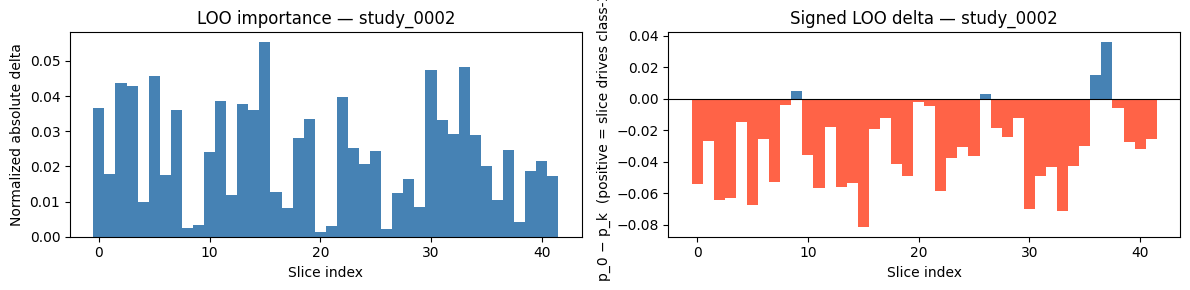

Top-3 most important slices: [15, 33, 30]


In [6]:
import matplotlib.pyplot as plt
from sliceheads.explain import compute_importance_dataset

mean_embedding = store.mean_embedding()
if mean_embedding is None:
    mean_embedding = store.compute_and_write_mean_embedding()

# Compute LOO for the first 10 test samples (fast subset)
imp_dict = compute_importance_dataset(
    head,
    emb_test[:10],
    ids_test[:10],
    mean_embedding,
)

# Show a bar chart for the first sample
sample_id = ids_test[0]
importance = imp_dict[sample_id]['importance']
signed = imp_dict[sample_id]['signed_importance']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

ax1.bar(range(len(importance)), importance, color='steelblue', width=1.0)
ax1.set_title(f'LOO importance — {sample_id}')
ax1.set_xlabel('Slice index')
ax1.set_ylabel('Normalized absolute delta')

colors = ['tomato' if s < 0 else 'steelblue' for s in signed]
ax2.bar(range(len(signed)), signed, color=colors, width=1.0)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title(f'Signed LOO delta — {sample_id}')
ax2.set_xlabel('Slice index')
ax2.set_ylabel('p_0 − p_k  (positive = slice drives class-1)')

plt.tight_layout()
plt.show()

print(f'Top-3 most important slices: {np.argsort(-importance)[:3].tolist()}')

## 6 — Plug into the benchmark runner

To run `MedianPoolClassifier` through `run_benchmark` (HPO + test eval), register it in the head
catalogue inside `sliceheads/hpo.py` and add a config block:

```python
# sliceheads/hpo.py — add to _HEAD_CLASSES:
_HEAD_CLASSES['MedianPoolClassifier'] = 'mypackage.heads.MedianPoolClassifier'
```

```yaml
# experiment.yaml — add a head block:
MedianPoolClassifier:
  enabled: true
  hyperparameters:
    C: [0.01, 0.1, 1.0, 10.0]
    class_weight: ["balanced"]
```

Then re-run `python run_experiment.py` and the new head participates in the benchmark alongside
all existing heads, with HPO, test evaluation, LOO importance, and results persistence.

---

## Checklist for a new head

| Requirement | Where |
|---|---|
| Subclass `BaseHead` | Class definition |
| Set `input_policy` to `"native_mask"` or `"adapter_mask"` | Class attribute |
| Implement `fit`, `predict_proba`, `_save_backend`, `_load_backend` | Four abstract methods |
| Return `predict_proba` of shape `[B, 2]` | Positive class in column 1 |
| Honour `mask` in every pooling/aggregation step (native-mask) | `_pool` or equivalent |
| Call `super().fit()` / `super().predict_proba()` to validate mask | Delegate to base |
| Implement `get_params()` with all constructor args | For HPO and save/load |
| Optionally implement `native_attention()` | Set `supports_native_attention = True` |